# Week 5 — Constrained Optimisation II
## KKT Conditions & Inequality Constraints

**Optimisation & Mathematical Methods for Economics**
The University of Edinburgh · School of Economics

---

Real economic constraints are often inequalities: budgets are upper bounds, quantities must be non-negative, capacity is limited. This week introduces the **Karush–Kuhn–Tucker (KKT) conditions**.

## 1. Inequality Constraints and KKT Conditions

**Problem:** Minimise $f(\mathbf{x})$ subject to $g_i(\mathbf{x}) \leq 0$, $i = 1,\ldots,m$ and $h_j(\mathbf{x}) = 0$, $j = 1,\ldots,p$.

**KKT conditions** (necessary for a local minimum under constraint qualification):
1. **Stationarity:** $\nabla f + \sum_i \mu_i \nabla g_i + \sum_j \lambda_j \nabla h_j = 0$
2. **Primal feasibility:** $g_i(\mathbf{x}) \leq 0$, $h_j(\mathbf{x}) = 0$
3. **Dual feasibility:** $\mu_i \geq 0$
4. **Complementary slackness:** $\mu_i g_i(\mathbf{x}) = 0$ for all $i$

## 2. Complementary Slackness

The condition $\mu_i g_i(\mathbf{x}) = 0$ means:
- Either the constraint is **binding** ($g_i = 0$) and the multiplier can be positive ($\mu_i > 0$)
- Or the constraint is **slack** ($g_i < 0$) and the multiplier must be zero ($\mu_i = 0$)

Economically: a resource has a positive shadow price only if it is fully used.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Example: Minimise f(x,y) = (x-3)^2 + (y-2)^2
# subject to: x + y <= 4, x >= 0, y >= 0
result = minimize(
    fun=lambda x: (x[0]-3)**2 + (x[1]-2)**2,
    x0=[1, 1],
    constraints=[
        {'type': 'ineq', 'fun': lambda x: 4 - x[0] - x[1]},  # x+y <= 4
    ],
    bounds=[(0, None), (0, None)]
)

print(f"Optimal x* = ({result.x[0]:.4f}, {result.x[1]:.4f})")
print(f"Minimum f* = {result.fun:.4f}")
print(f"x + y = {sum(result.x):.4f} (constraint bound = 4)")
if abs(sum(result.x) - 4) < 0.01:
    print("=> Budget constraint is BINDING")

Optimal x* = (2.5000, 1.5000)
Minimum f* = 0.5000
x + y = 4.0000 (constraint bound = 4)
=> Budget constraint is BINDING


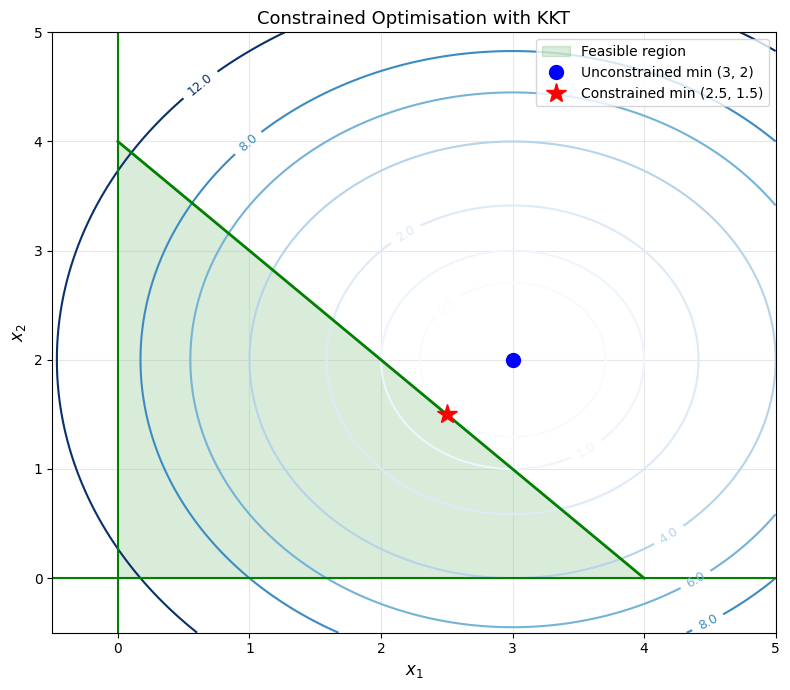

In [2]:
# Visualise the constrained optimisation
x1 = np.linspace(-0.5, 5, 300)
x2 = np.linspace(-0.5, 5, 300)
X1, X2 = np.meshgrid(x1, x2)
Z = (X1-3)**2 + (X2-2)**2

fig, ax = plt.subplots(figsize=(8, 7))

# Objective contours
cs = ax.contour(X1, X2, Z, levels=[0.5, 1, 2, 4, 6, 8, 12], cmap='Blues')
ax.clabel(cs, inline=True, fontsize=9)

# Feasible region
ax.fill([0, 4, 0, 0], [0, 0, 4, 0], alpha=0.15, color='green', label='Feasible region')
ax.plot([0, 4], [4, 0], 'g-', linewidth=2)
ax.axhline(0, color='g', linewidth=1.5)
ax.axvline(0, color='g', linewidth=1.5)

# Unconstrained and constrained optima
ax.plot(3, 2, 'bo', markersize=10, label='Unconstrained min (3, 2)')
ax.plot(result.x[0], result.x[1], 'r*', markersize=15, label=f'Constrained min ({result.x[0]:.1f}, {result.x[1]:.1f})')

ax.set_xlim(-0.5, 5); ax.set_ylim(-0.5, 5)
ax.set_xlabel('$x_1$', fontsize=12); ax.set_ylabel('$x_2$', fontsize=12)
ax.set_title('Constrained Optimisation with KKT', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Portfolio Choice with Short-Selling Constraints

An investor allocates wealth across $n$ assets to minimise portfolio variance $\mathbf{w}^T \Sigma \mathbf{w}$ subject to:
- Target return: $\mathbf{w}^T \boldsymbol{\mu} \geq r_{\min}$
- Weights sum to 1: $\sum w_i = 1$
- No short-selling: $w_i \geq 0$

The no-short-selling constraints are inequalities — KKT conditions apply.

In [3]:
# Minimum variance portfolio with no short-selling
np.random.seed(42)
n = 4
mu = np.array([0.08, 0.12, 0.06, 0.10])  # expected returns
Sigma = np.array([
    [0.04, 0.006, 0.002, 0.01],
    [0.006, 0.09, 0.009, 0.015],
    [0.002, 0.009, 0.025, 0.005],
    [0.01, 0.015, 0.005, 0.06]
])

r_target = 0.09

result = minimize(
    fun=lambda w: w @ Sigma @ w,
    x0=np.ones(n)/n,
    constraints=[
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: w @ mu - r_target}
    ],
    bounds=[(0, 1)]*n
)

print("Optimal portfolio weights:")
assets = ['Asset A', 'Asset B', 'Asset C', 'Asset D']
for a, w in zip(assets, result.x):
    binding = "(binding: w=0)" if w < 0.001 else ""
    print(f"  {a}: {w:.4f}  {binding}")
print(f"\nPortfolio return: {result.x @ mu:.4f}")
print(f"Portfolio std dev: {np.sqrt(result.fun):.4f}")

Optimal portfolio weights:
  Asset A: 0.2878  
  Asset B: 0.2353  
  Asset C: 0.2238  
  Asset D: 0.2532  

Portfolio return: 0.0900
Portfolio std dev: 0.1386


## Exercises

<details><summary><b>Exercise 1:</b> A consumer maximises $u = \ln(x_1) + \ln(x_2)$ subject to $2x_1 + 3x_2 \leq 12$, $x_1 \geq 0$, $x_2 \geq 0$. Write down the KKT conditions and solve.</summary>

The budget constraint will be binding (since $u$ is monotonically increasing).
$x_1^* = 3$, $x_2^* = 2$, $\mu = 1/6$ (shadow price of the budget).
</details>